### Ocean Basin Masks

In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.path as mpath
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from mom6_tools.m6plot import xyplot
from mom6_tools.m6toolbox import genBasinMasks 
import datetime
import numpy 
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

Basemap module not found. Some regional plots may not function properly


In [2]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260528


In [3]:
# The following parameters must be set accordingly
######################################################
# case name - must be changed for each configuration
grid_name = 'tx2_0v1'
# Path to the grid
grd_path = "../mesh/tx2_0v1_grid.nc"
# add your name and email address below
author = 'William Xu (chengz@ucar.edu)'

In [4]:
grd = xr.open_dataset(grd_path)
grd

<xarray.Dataset> Size: 4MB
Dimensions:  (ny: 128, nx: 180, nxp: 181, nyp: 129)
Dimensions without coordinates: ny, nx, nxp, nyp
Data variables: (12/20)
    tlon     (ny, nx) float64 184kB ...
    tlat     (ny, nx) float64 184kB ...
    ulon     (ny, nxp) float64 185kB ...
    ulat     (ny, nxp) float64 185kB ...
    vlon     (nyp, nx) float64 186kB ...
    vlat     (nyp, nx) float64 186kB ...
    ...       ...
    tarea    (ny, nx) float64 184kB ...
    tmask    (ny, nx) float64 184kB ...
    angle    (ny, nx) float64 184kB ...
    depth    (ny, nx) float64 184kB ...
    ar       (ny, nx) float64 184kB ...
    egs      (ny, nx) float64 184kB ...
Attributes:
    Description:  CESM MOM6 2.0 degree grid
    Author:       Frank, Fred, Gustavo, William (chengz@ucar.edu)
    Created:      2026-05-27T13:37:18.621282
    type:         Glogal 2.0 degree grid file

### Default basins from mom6-tools

In [5]:
basin_code = genBasinMasks(grd.tlon.values, grd.tlat.values, grd.depth.values,xda=True).rename('basin_masks')

In [6]:
basin_code

<xarray.DataArray 'basin_masks' (region: 16, yh: 128, xh: 180)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(16, 128, 180))
Coordinates:
  * region   (region) <U17 1kB 'Global' 'PersianGulf' ... 'GulfOfMexico'
Dimensions without coordinates: yh, xh

#### Check mask for all the regions

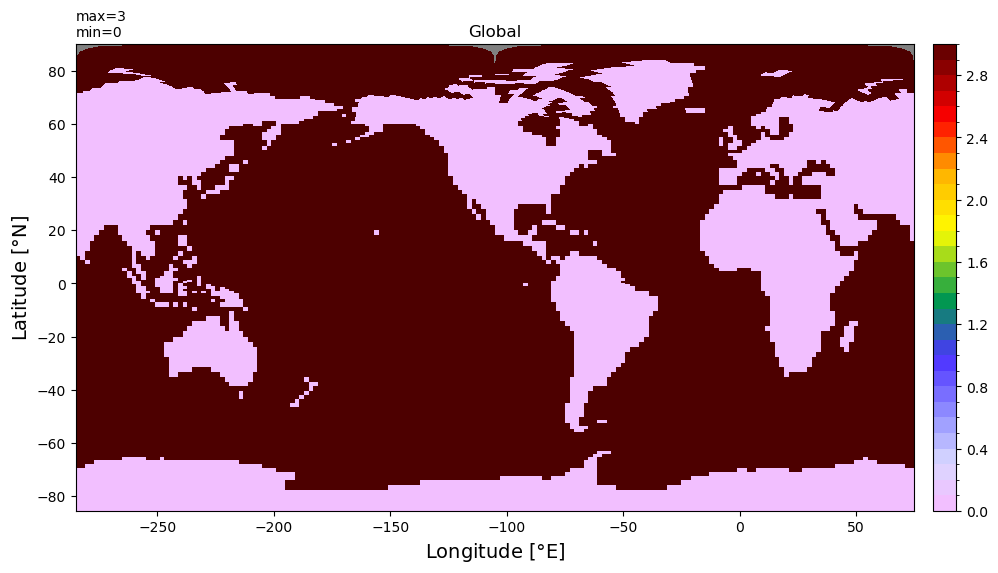

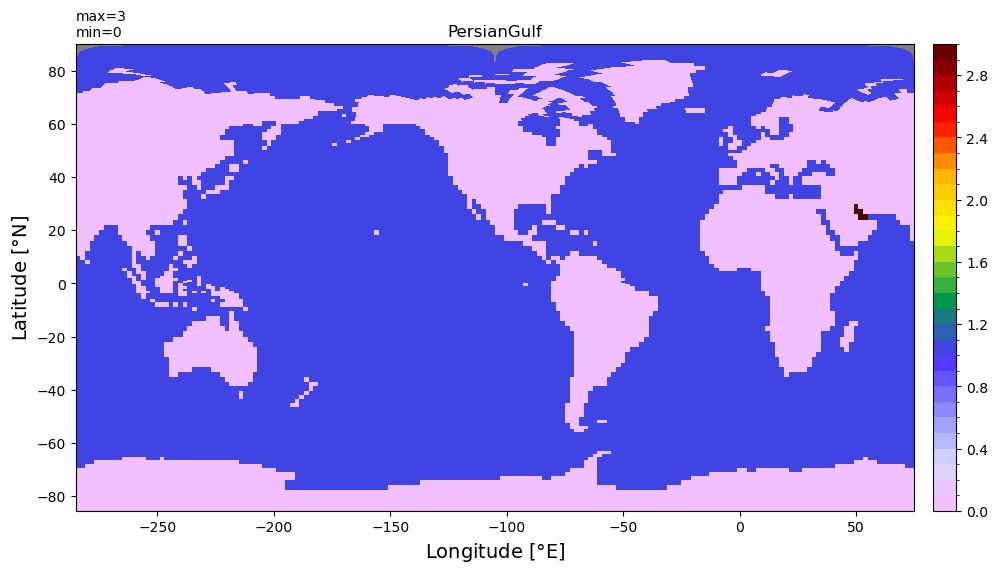

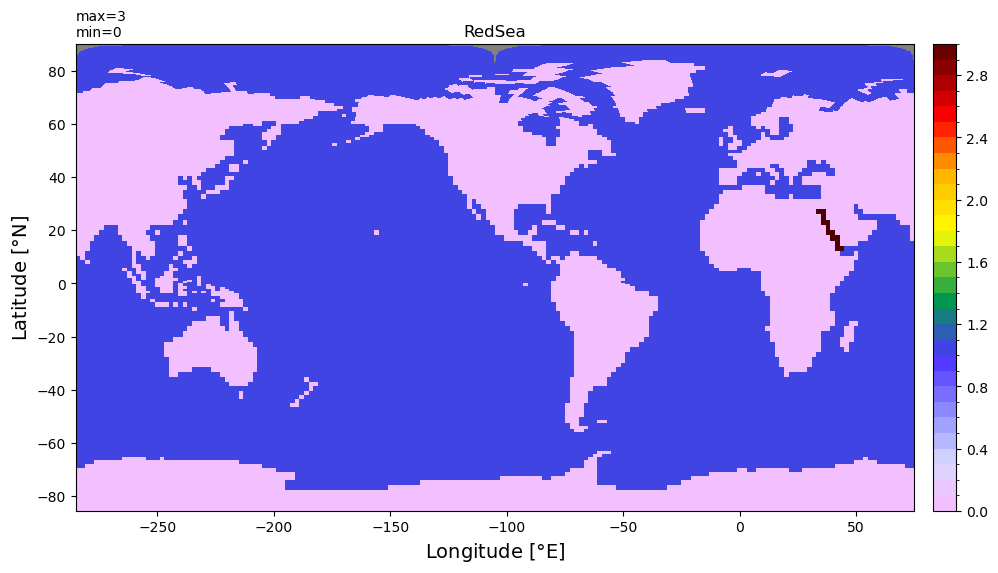

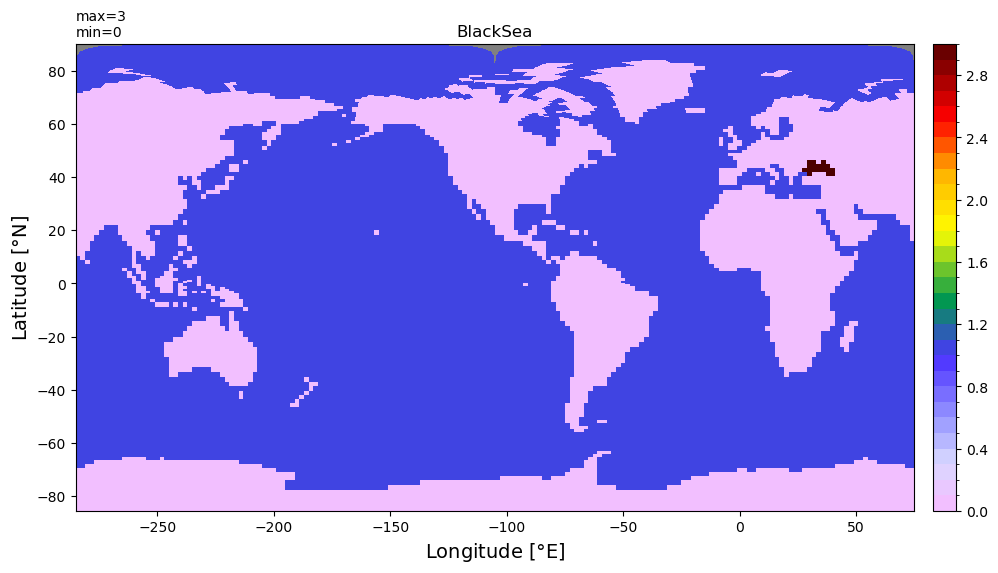

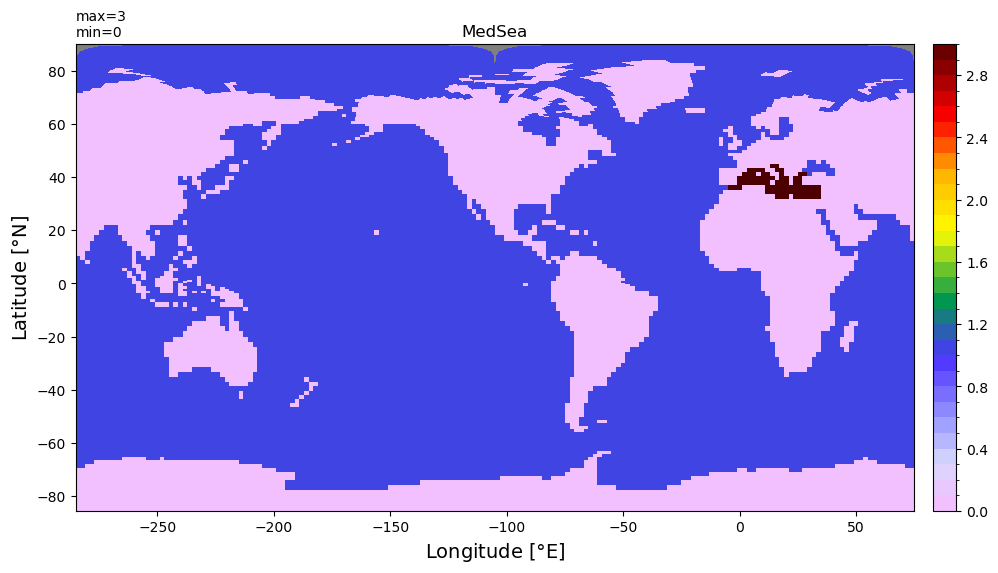

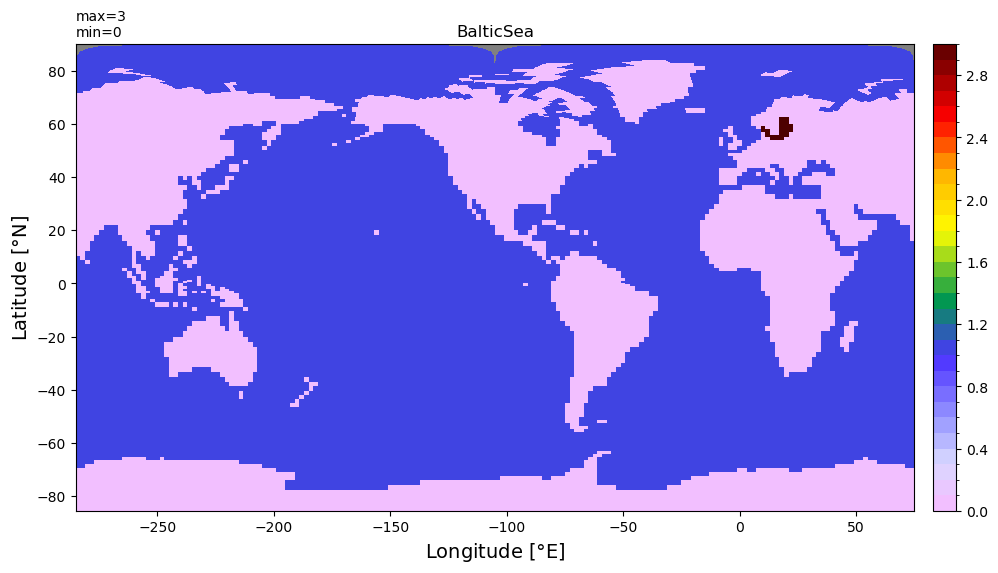

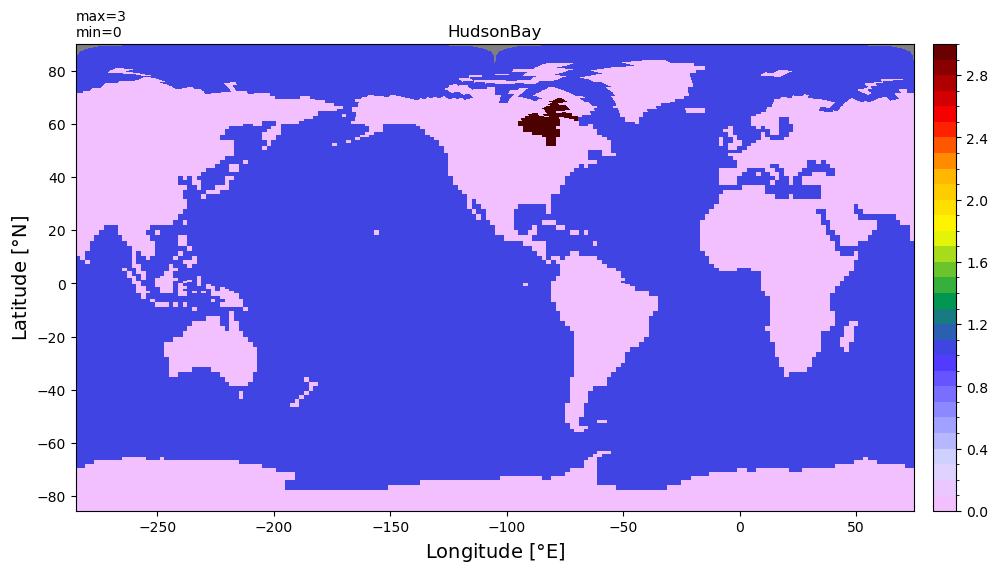

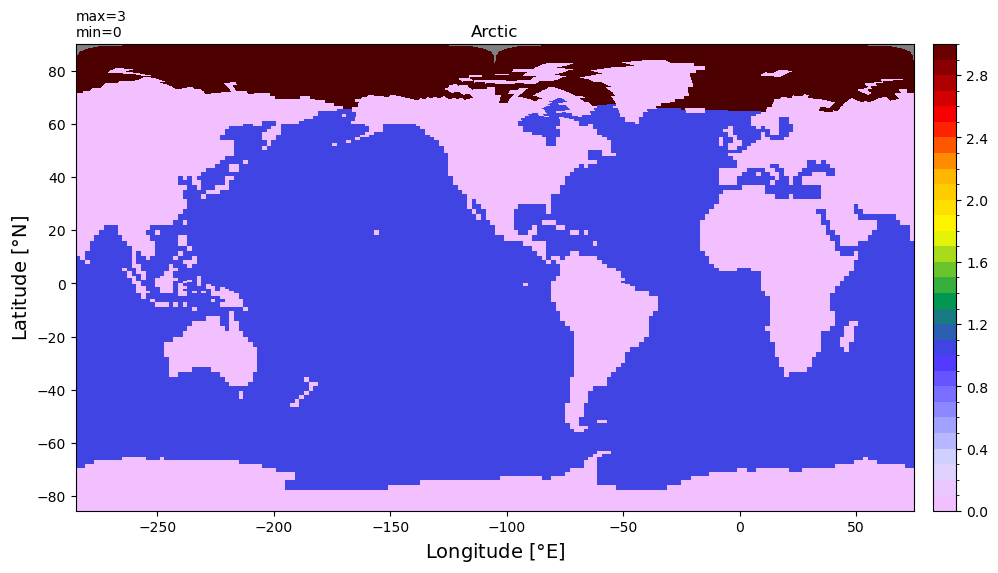

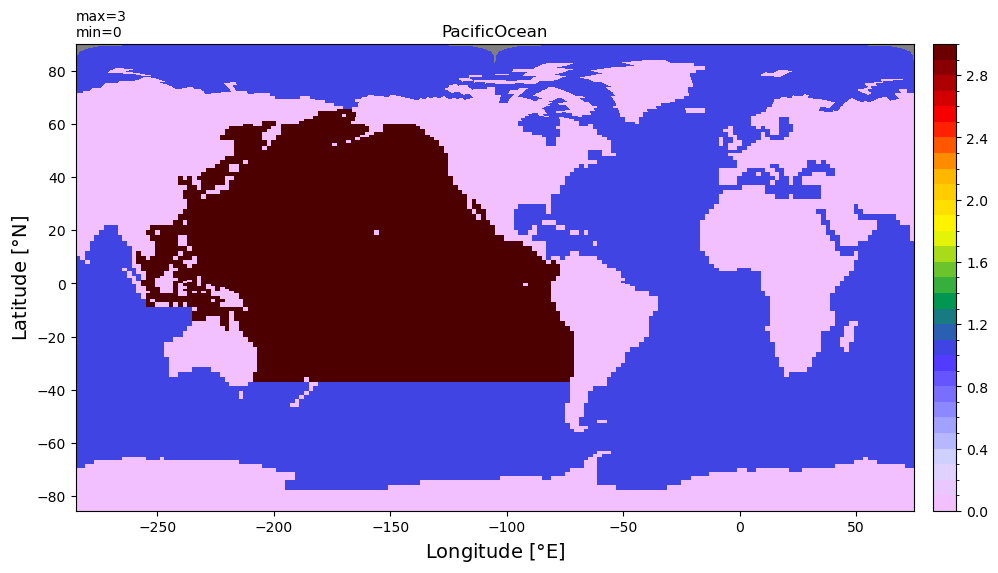

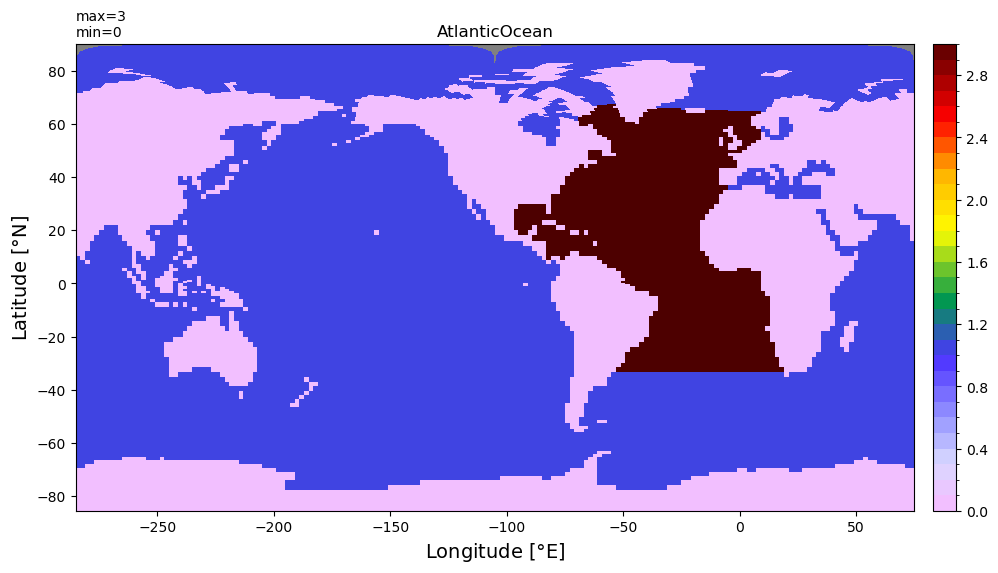

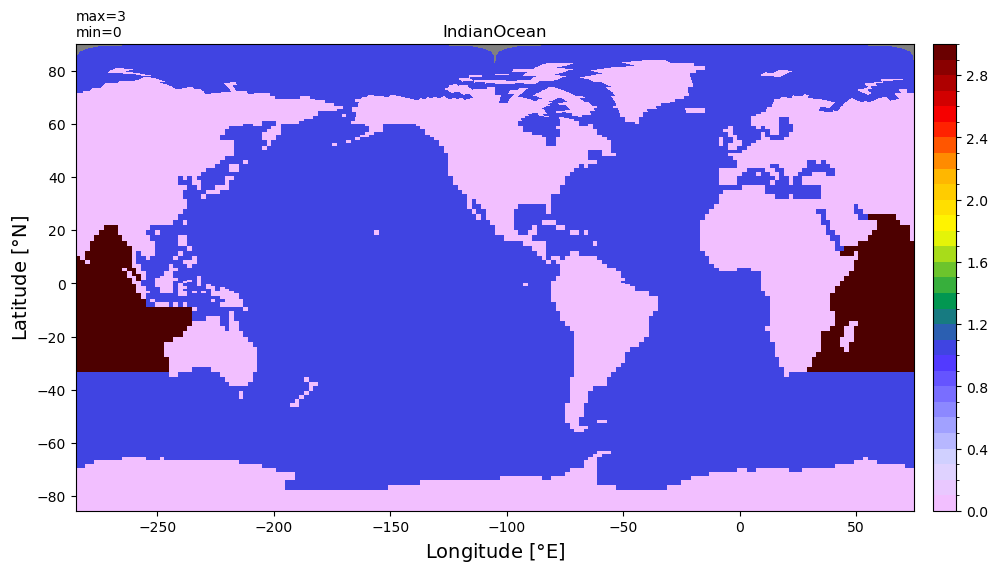

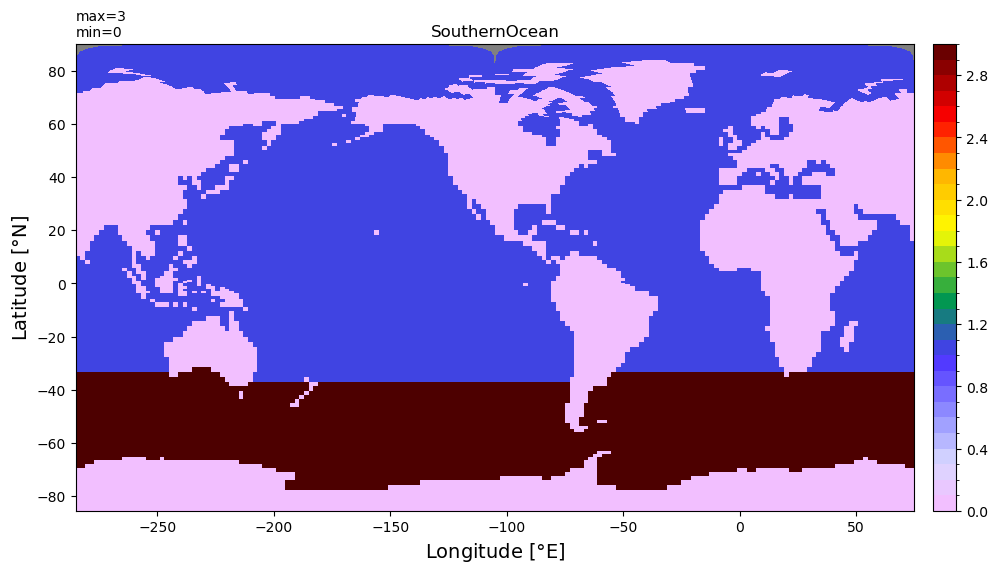

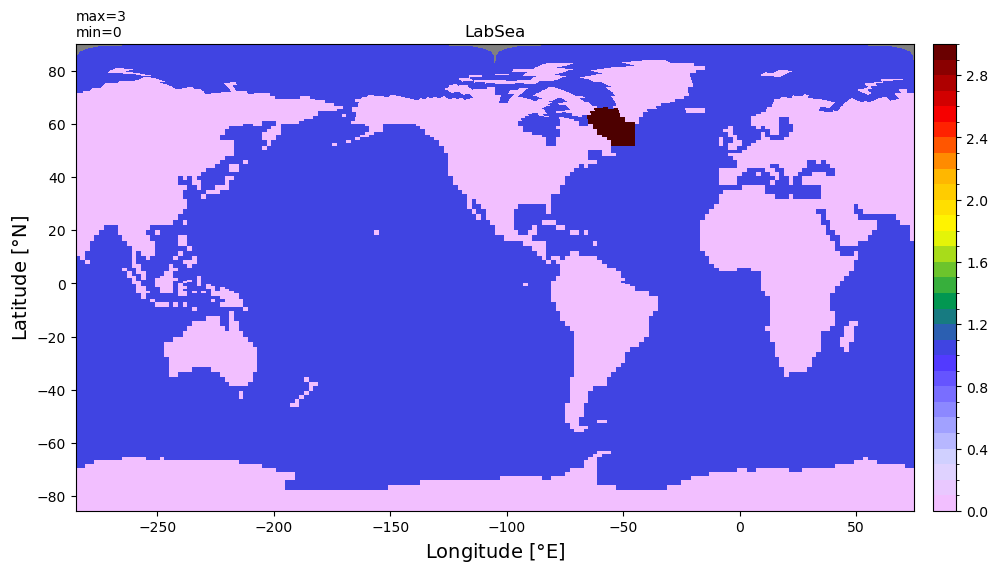

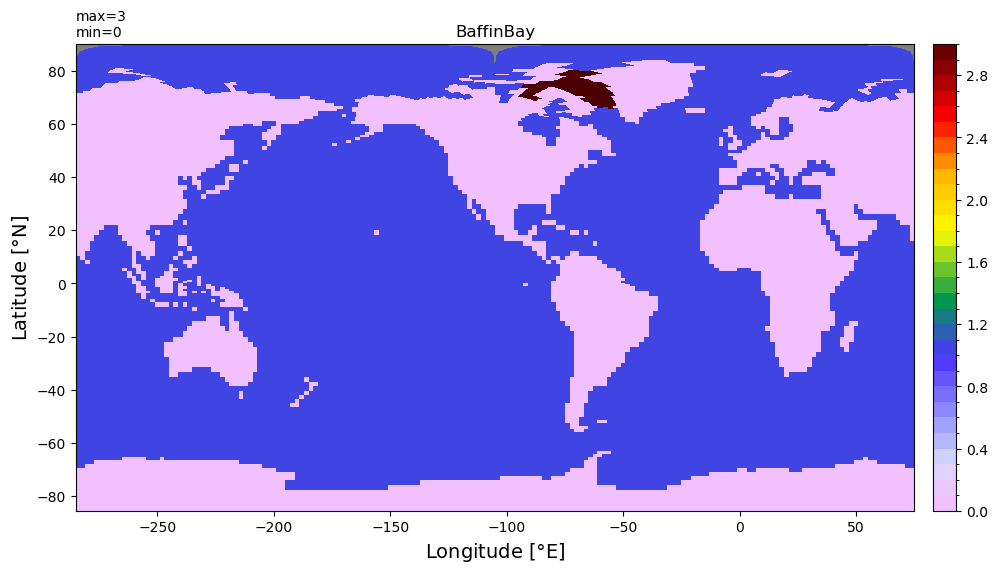

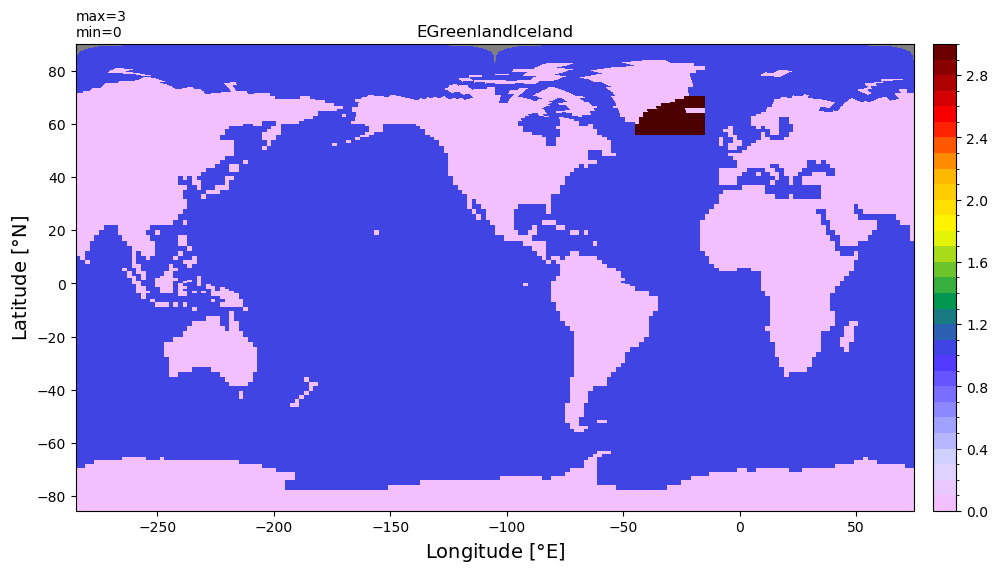

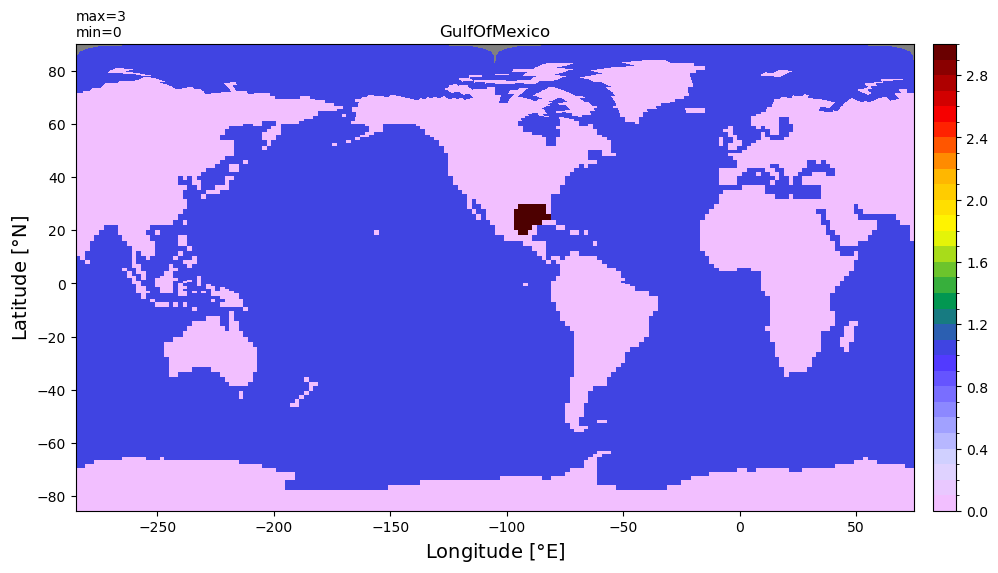

In [7]:
for r in range(len(basin_code.region)):
    xyplot((basin_code[0,:]+basin_code[r,:]*2).values, grd.tlon, grd.tlat,
          title=str(basin_code['region'][r].values))

#### Plot all masks in a single map

In [8]:
a= xr.where(basin_code[1]==1, 1, numpy.nan)

In [9]:
val_ls = []
for key, val in mcolors.TABLEAU_COLORS.items():
    val_ls.append(val)
print(val_ls)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


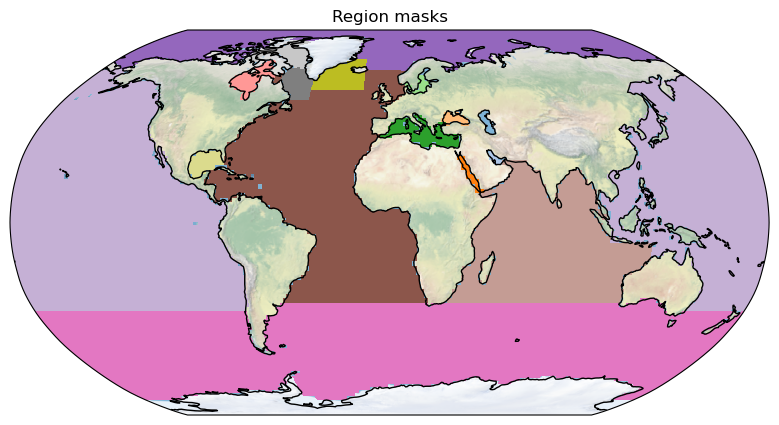

In [10]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

for r in range(1,len(basin_code.region)):
    mask= xr.where(basin_code[r,:]==1, r, numpy.nan)
    
    
    pc = ax.pcolormesh(grd.qlon, grd.qlat, mask.values, cmap=plt.cm.tab20, 
              transform=ccrs.PlateCarree(),vmin=0, vmax=(len(basin_code.region)+1))

ax.set_title('Region masks')
ax.set_global()
ax.stock_img()
ax.coastlines();

### Add new basins into basin_code

#### SouthernOcean60S

In [11]:
# Expand dimensions to match `region` dimension
new_region_mask = xr.where(basin_code.sel(region='SouthernOcean') == 1, 1, 0).where(grd.tlat.rename({'ny':'yh','nx':'xh'})<=-60).fillna(0)

# Assign a new region index (e.g., 14 if original regions are indexed 0-13)
new_region_mask = new_region_mask.expand_dims(dim={"region": [len(basin_code.region)]})  # Change to the appropriate index

# Concatenate with the existing `basin_masks`
basin_code = xr.concat([basin_code, new_region_mask], dim="region")

# Update region name

# Convert region names to a list, modify the last element, and reassign
region_names = basin_code.region.values.tolist()
region_names[-1] = 'SouthernOcean60S'  # Replace last region name

# Reassign the modified region names to the dataset
basin_code = basin_code.assign_coords(region=("region", region_names))

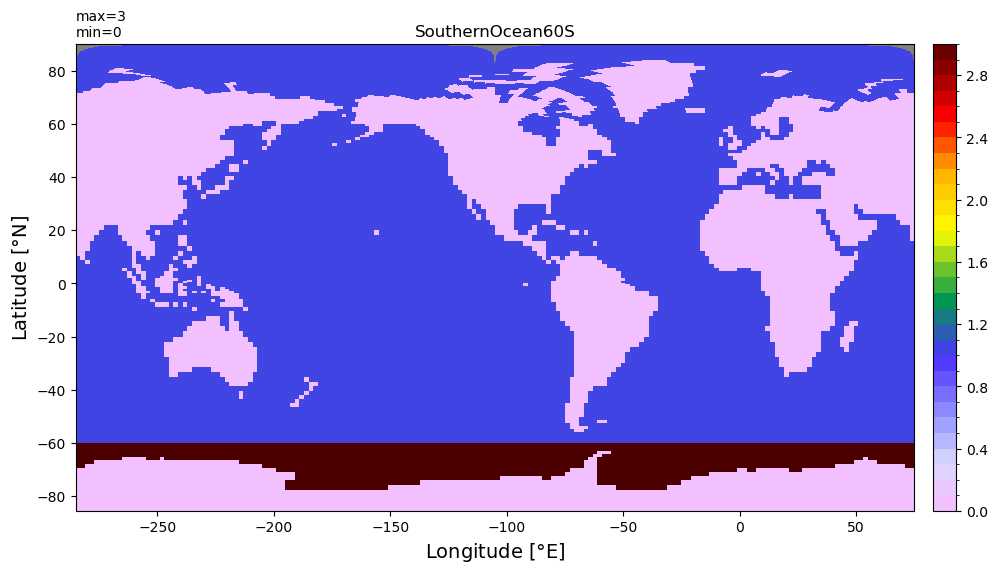

In [12]:
r = len(basin_code.region)-1
(basin_code[0,:]+basin_code[r,:]*2).values
xyplot((basin_code[0,:]+basin_code[r,:]*2).values, grd.tlon, grd.tlat,
          title=str(basin_code['region'][r].values))

### Save as netCDF

In [13]:
# Global attrs
basin_code.attrs['description'] = 'Basin masks for ' + grid_name
basin_code.attrs['author'] = author
basin_code.attrs['date'] = today
basin_code.attrs['infile'] = grd_path
basin_code.attrs['url'] = 'https://github.com/NCAR/tx2_0/basin_masks'
# save
fname = 'basin_masks_{}_{}.nc'.format(grid_name, today)

basin_code.to_netcdf(fname, encoding={'basin_masks': {'_FillValue': None}})